In [3]:
# ============================================================
# LAB06 - All source code in one place (Jupyter notebook style)
# AI ATTRIBUTION:
#   - V1 (CustomKNN) + modules: student's own modularization (Lab05)
#   - V3 (GenAIKNN) + harness helpers: generated by Claude (Anthropic)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from collections import Counter
import warnings
warnings.filterwarnings('ignore')


# ---------- MODULE 1: ENCODING ----------
def encode_categorical(df, columns):
    df_encoded = df.copy()
    encoders = {}
    for col in columns:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        encoders[col] = le
    return df_encoded, encoders


# ---------- MODULE 2: IMPUTATION (fixed for pandas 2.x/3.x) ----------
def impute_missing(df, strategy='mean'):
    df_imputed = df.copy()
    for col in df_imputed.columns:
        if df_imputed[col].isnull().sum() > 0:
            if strategy == 'mean':
                fill_val = df_imputed[col].mean()
            elif strategy == 'median':
                fill_val = df_imputed[col].median()
            elif strategy == 'mode':
                fill_val = df_imputed[col].mode()[0]
            else:
                raise ValueError("strategy must be 'mean', 'median', or 'mode'")
            df_imputed[col] = df_imputed[col].fillna(fill_val)
    return df_imputed


# ---------- MODULE 3: DISTANCE ----------
def calculate_distance(point1, point2, metric='euclidean'):
    p1 = np.array(point1, dtype=float)
    p2 = np.array(point2, dtype=float)
    if metric == 'euclidean':
        return np.sqrt(np.sum((p1 - p2) ** 2))
    elif metric == 'manhattan':
        return np.sum(np.abs(p1 - p2))
    elif metric == 'minkowski':
        return np.sum(np.abs(p1 - p2) ** 3) ** (1 / 3)
    else:
        raise ValueError("Unsupported metric")


# ---------- MODULE 4: SORTING ----------
def bubble_sort(arr):
    a = list(arr)
    n = len(a)
    for i in range(n):
        for j in range(0, n - i - 1):
            if a[j][0] > a[j + 1][0]:
                a[j], a[j + 1] = a[j + 1], a[j]
    return a


def insertion_sort(arr):
    a = list(arr)
    for i in range(1, len(a)):
        key = a[i]
        j = i - 1
        while j >= 0 and a[j][0] > key[0]:
            a[j + 1] = a[j]
            j -= 1
        a[j + 1] = key
    return a


def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    return _merge(merge_sort(arr[:mid]), merge_sort(arr[mid:]))


def _merge(left, right):
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i][0] <= right[j][0]:
            result.append(left[i]); i += 1
        else:
            result.append(right[j]); j += 1
    result.extend(left[i:]); result.extend(right[j:])
    return result


def sort_distances(distances, algorithm='merge'):
    if algorithm == 'bubble':
        return bubble_sort(distances)
    elif algorithm == 'insertion':
        return insertion_sort(distances)
    elif algorithm == 'merge':
        return merge_sort(distances)
    else:
        raise ValueError("Unknown sorting algorithm")


# ---------- MODULE 5: NEIGHBORS ----------
def identify_neighbors(distances, k):
    sorted_d = sorted(distances, key=lambda x: (x[0], x[1]))
    return sorted_d[:k]


# ---------- MODULE 6: MAJORITY VOTE ----------
def majority_vote(neighbors, weighted=False):
    if weighted:
        votes = {}
        for dist, _, label in neighbors:
            w = 1.0 / (dist + 1e-9)
            votes[label] = votes.get(label, 0) + w
    else:
        votes = Counter([label for _, _, label in neighbors])
    max_votes = max(votes.values())
    winners = sorted([lbl for lbl, v in votes.items() if v == max_votes])
    return winners[0]


# ---------- V1: CUSTOM kNN (student's own) ----------
class CustomKNN:
    def __init__(self, k=3, metric='euclidean', sort_algo='merge', weighted=False):
        self.k = k
        self.metric = metric
        self.sort_algo = sort_algo
        self.weighted = weighted
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.array(X, dtype=float)
        self.y_train = np.array(y)
        return self

    def _predict_one(self, x):
        distances = []
        for idx, x_train in enumerate(self.X_train):
            d = calculate_distance(x, x_train, self.metric)
            distances.append((d, idx, self.y_train[idx]))
        sorted_distances = sort_distances(distances, self.sort_algo)
        neighbors = identify_neighbors(sorted_distances, self.k)
        return majority_vote(neighbors, weighted=self.weighted)

    def predict(self, X):
        X = np.array(X, dtype=float)
        return np.array([self._predict_one(x) for x in X])

    def score(self, X, y):
        return np.mean(self.predict(X) == np.array(y))


# ---------- V3: GENAI kNN (Claude-generated) ----------
class GenAIKNN:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=float)
        self.y_train = np.asarray(y)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        predictions = []
        for x in X:
            diffs = self.X_train - x
            dists = np.sqrt(np.einsum('ij,ij->i', diffs, diffs))
            k_idx = np.argsort(dists)[:self.k]
            labels = self.y_train[k_idx]
            counts = np.bincount(labels)
            predictions.append(np.argmax(counts))
        return np.array(predictions)

    def score(self, X, y):
        return np.mean(self.predict(X) == np.asarray(y))


# ---------- HELPER: LOAD & PREPARE ----------
def load_and_prepare(file_path, n_rows=500, test_size=0.3, random_state=42):
    df = pd.read_excel(file_path, sheet_name='marketing_campaign')
    df_sub = df.head(n_rows).copy()
    drop_cols = ['ID', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue']
    df_sub = df_sub.drop(columns=[c for c in drop_cols if c in df_sub.columns])
    target = 'Response'
    y = df_sub[target].values
    X_df = df_sub.drop(columns=[target]).copy()

    num_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_df.select_dtypes(include=['object']).columns.tolist()
    for col in num_cols:
        if X_df[col].isnull().any():
            X_df[col] = X_df[col].fillna(X_df[col].mean())
    for col in cat_cols:
        if X_df[col].isnull().any():
            X_df[col] = X_df[col].fillna(X_df[col].mode()[0])

    X_enc, _ = encode_categorical(X_df, cat_cols)
    X_enc = X_enc.apply(pd.to_numeric, errors='coerce').fillna(0)
    scaler = StandardScaler()
    X = scaler.fit_transform(X_enc.values)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test


# ---------- HELPER: EVALUATE ----------
def evaluate(y_true, y_pred):
    return {
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0)
    }


print("✓ Cell 1 done: All modules, classes, and helpers loaded.")

✓ Cell 1 done: All modules, classes, and helpers loaded.


In [4]:
# ============================================================
# CELL 2: UNIT TESTS (unittest)
# AI ATTRIBUTION: tests generated by Claude (Anthropic)
# ============================================================
import unittest

class TestEncoding(unittest.TestCase):
    def test_encode_basic(self):
        df = pd.DataFrame({'Color': ['Red', 'Blue', 'Red', 'Green']})
        encoded, enc = encode_categorical(df, ['Color'])
        self.assertEqual(encoded['Color'].tolist(), [2, 0, 2, 1])
        self.assertIn('Color', enc)

    def test_encode_handles_nan_as_string(self):
        df = pd.DataFrame({'X': ['A', None, 'B']})
        encoded, _ = encode_categorical(df, ['X'])
        self.assertEqual(encoded['X'].nunique(), 3)


class TestImputation(unittest.TestCase):
    def test_impute_mean(self):
        df = pd.DataFrame({'A': [1.0, 2.0, np.nan, 4.0]})
        out = impute_missing(df, strategy='mean')
        self.assertEqual(out['A'].isnull().sum(), 0)
        self.assertAlmostEqual(out['A'].iloc[2], 7/3, places=3)

    def test_impute_median(self):
        df = pd.DataFrame({'A': [1.0, 5.0, np.nan, 3.0]})
        out = impute_missing(df, strategy='median')
        self.assertEqual(out['A'].iloc[2], 3.0)

    def test_impute_mode(self):
        df = pd.DataFrame({'A': [1.0, 1.0, np.nan, 2.0]})
        out = impute_missing(df, strategy='mode')
        self.assertEqual(out['A'].iloc[2], 1.0)

    def test_invalid_strategy(self):
        df = pd.DataFrame({'A': [1.0, np.nan]})
        with self.assertRaises(ValueError):
            impute_missing(df, strategy='wrong')


class TestDistance(unittest.TestCase):
    def test_euclidean(self):
        self.assertAlmostEqual(calculate_distance([0,0],[3,4],'euclidean'), 5.0, places=3)
    def test_manhattan(self):
        self.assertEqual(calculate_distance([0,0],[3,4],'manhattan'), 7.0)
    def test_minkowski(self):
        self.assertAlmostEqual(calculate_distance([0,0],[1,1],'minkowski'), 2**(1/3), places=3)
    def test_invalid(self):
        with self.assertRaises(ValueError):
            calculate_distance([0,0],[1,1],'chebyshev')


class TestSorting(unittest.TestCase):
    def setUp(self):
        self.u = [(3.5,0,'a'),(1.2,1,'b'),(2.8,2,'c'),(0.9,3,'d')]
    def test_bubble(self):
        self.assertEqual([x[0] for x in bubble_sort(self.u)], [0.9,1.2,2.8,3.5])
    def test_insertion(self):
        self.assertEqual([x[0] for x in insertion_sort(self.u)], [0.9,1.2,2.8,3.5])
    def test_merge(self):
        self.assertEqual([x[0] for x in merge_sort(self.u)], [0.9,1.2,2.8,3.5])
    def test_dispatcher(self):
        for algo in ['bubble','insertion','merge']:
            self.assertEqual(sort_distances(self.u, algo)[0][0], 0.9)


class TestNeighbors(unittest.TestCase):
    def test_basic(self):
        d = [(1.0,0,'a'),(2.0,1,'b'),(0.5,2,'c')]
        out = identify_neighbors(d, 2)
        self.assertEqual(out[0][2], 'c')
        self.assertEqual(out[1][2], 'a')
    def test_tie_break(self):
        d = [(1.0,5,'x'),(1.0,2,'y'),(2.0,1,'z')]
        out = identify_neighbors(d, 2)
        self.assertEqual(out[0][1], 2)
        self.assertEqual(out[1][1], 5)


class TestVote(unittest.TestCase):
    def test_unweighted(self):
        n = [(0.1,0,'A'),(0.2,1,'A'),(0.3,2,'B')]
        self.assertEqual(majority_vote(n, weighted=False), 'A')
    def test_weighted(self):
        n = [(0.01,0,'B'),(5.0,1,'A'),(5.0,2,'A')]
        self.assertEqual(majority_vote(n, weighted=True), 'B')
    def test_tie(self):
        n = [(1.0,0,'B'),(1.0,1,'A')]
        self.assertEqual(majority_vote(n, weighted=False), 'A')


class TestCustomKNN(unittest.TestCase):
    def setUp(self):
        self.X = np.array([[0,0],[0,1],[10,10],[10,11]], dtype=float)
        self.y = np.array([0,0,1,1])
    def test_separation(self):
        m = CustomKNN(k=1).fit(self.X, self.y)
        self.assertEqual(m.predict(np.array([[0.1,0.1]]))[0], 0)
        self.assertEqual(m.predict(np.array([[9.9,10.1]]))[0], 1)
    def test_score(self):
        m = CustomKNN(k=1).fit(self.X, self.y)
        self.assertEqual(m.score(self.X, self.y), 1.0)


class TestGenAIKNN(unittest.TestCase):
    def test_matches(self):
        X = np.array([[0,0],[0,1],[10,10],[10,11]], dtype=float)
        y = np.array([0,0,1,1])
        m = GenAIKNN(k=1).fit(X, y)
        self.assertTrue(np.array_equal(m.predict(X), y))


# --- RUN TESTS ---
unittest.main(argv=['ignored'], exit=False, verbosity=2)

test_score (__main__.TestCustomKNN.test_score) ... ok
test_separation (__main__.TestCustomKNN.test_separation) ... ok
test_euclidean (__main__.TestDistance.test_euclidean) ... ok
test_invalid (__main__.TestDistance.test_invalid) ... ok
test_manhattan (__main__.TestDistance.test_manhattan) ... ok
test_minkowski (__main__.TestDistance.test_minkowski) ... ok
test_encode_basic (__main__.TestEncoding.test_encode_basic) ... ok
test_encode_handles_nan_as_string (__main__.TestEncoding.test_encode_handles_nan_as_string) ... ok
test_matches (__main__.TestGenAIKNN.test_matches) ... ok
test_impute_mean (__main__.TestImputation.test_impute_mean) ... ok
test_impute_median (__main__.TestImputation.test_impute_median) ... ok
test_impute_mode (__main__.TestImputation.test_impute_mode) ... ok
test_invalid_strategy (__main__.TestImputation.test_invalid_strategy) ... ok
test_basic (__main__.TestNeighbors.test_basic) ... ok
test_tie_break (__main__.TestNeighbors.test_tie_break) ... ok
test_bubble (__main__

In [10]:
# ============================================================
# CELL 3: A3 - Compare 3 versions of kNN
# ============================================================
file_path = r"C:\Users\thanu\Downloads\Lab Session Data (1) (1).xlsx"
k = 5
n_runs = 10

X_train, X_test, y_train, y_test = load_and_prepare(file_path)

# ---------- V1: Custom kNN ----------
v1_fit, v1_pred = [], []
for _ in range(n_runs):
    m = CustomKNN(k=k, metric='euclidean', sort_algo='merge')
    t0 = time.perf_counter(); m.fit(X_train, y_train); t1 = time.perf_counter()
    y_pred1 = m.predict(X_test); t2 = time.perf_counter()
    v1_fit.append(t1 - t0); v1_pred.append(t2 - t1)
r1 = {**evaluate(y_test, y_pred1),
      'Fit Time (s)': np.mean(v1_fit),
      'Pred Time (s)': np.mean(v1_pred),
      'Total Time (s)': np.mean(v1_fit) + np.mean(v1_pred)}

# ---------- V2: sklearn kNN ----------
v2_fit, v2_pred = [], []
for _ in range(n_runs):
    m = KNeighborsClassifier(n_neighbors=k)
    t0 = time.perf_counter(); m.fit(X_train, y_train); t1 = time.perf_counter()
    y_pred2 = m.predict(X_test); t2 = time.perf_counter()
    v2_fit.append(t1 - t0); v2_pred.append(t2 - t1)
r2 = {**evaluate(y_test, y_pred2),
      'Fit Time (s)': np.mean(v2_fit),
      'Pred Time (s)': np.mean(v2_pred),
      'Total Time (s)': np.mean(v2_fit) + np.mean(v2_pred)}

# ---------- V3: GenAI kNN ----------
v3_fit, v3_pred = [], []
for _ in range(n_runs):
    m = GenAIKNN(k=k)
    t0 = time.perf_counter(); m.fit(X_train, y_train); t1 = time.perf_counter()
    y_pred3 = m.predict(X_test); t2 = time.perf_counter()
    v3_fit.append(t1 - t0); v3_pred.append(t2 - t1)
r3 = {**evaluate(y_test, y_pred3),
      'Fit Time (s)': np.mean(v3_fit),
      'Pred Time (s)': np.mean(v3_pred),
      'Total Time (s)': np.mean(v3_fit) + np.mean(v3_pred)}

# ---------- Print table ----------
print("=" * 100)
print(f"A3: Performance comparison of 3 kNN versions (k={k}, {n_runs} runs each)")
print("=" * 100)

hdr = f"{'Version':<15} | {'Acc':>7} | {'Prec':>7} | {'Rec':>7} | {'F1':>7} | {'Fit(s)':>9} | {'Pred(s)':>9} | {'Total(s)':>10}"
print(hdr); print("-" * len(hdr))
for name, r in [('Your kNN', r1), ('sklearn kNN', r2), ('GenAI kNN', r3)]:
    print(f"{name:<15} | {r['Accuracy']:>7.4f} | {r['Precision']:>7.4f} | "
          f"{r['Recall']:>7.4f} | {r['F1']:>7.4f} | {r['Fit Time (s)']:>9.6f} | "
          f"{r['Pred Time (s)']:>9.6f} | {r['Total Time (s)']:>10.6f}")

# ---------- Save CSV ----------
df_out = pd.DataFrame({'Your kNN': r1, 'sklearn kNN': r2, 'GenAI kNN': r3}).T
df_out.to_csv("knn_comparison_lab06.csv")


A3: Performance comparison of 3 kNN versions (k=5, 10 runs each)
Version         |     Acc |    Prec |     Rec |      F1 |    Fit(s) |   Pred(s) |   Total(s)
--------------------------------------------------------------------------------------------
Your kNN        |  0.9000 |  0.7778 |  0.3500 |  0.4828 |  0.000036 |  1.346224 |   1.346260
sklearn kNN     |  0.9000 |  0.7778 |  0.3500 |  0.4828 |  0.001514 |  0.010483 |   0.011997
GenAI kNN       |  0.9000 |  0.7778 |  0.3500 |  0.4828 |  0.000004 |  0.013229 |   0.013233


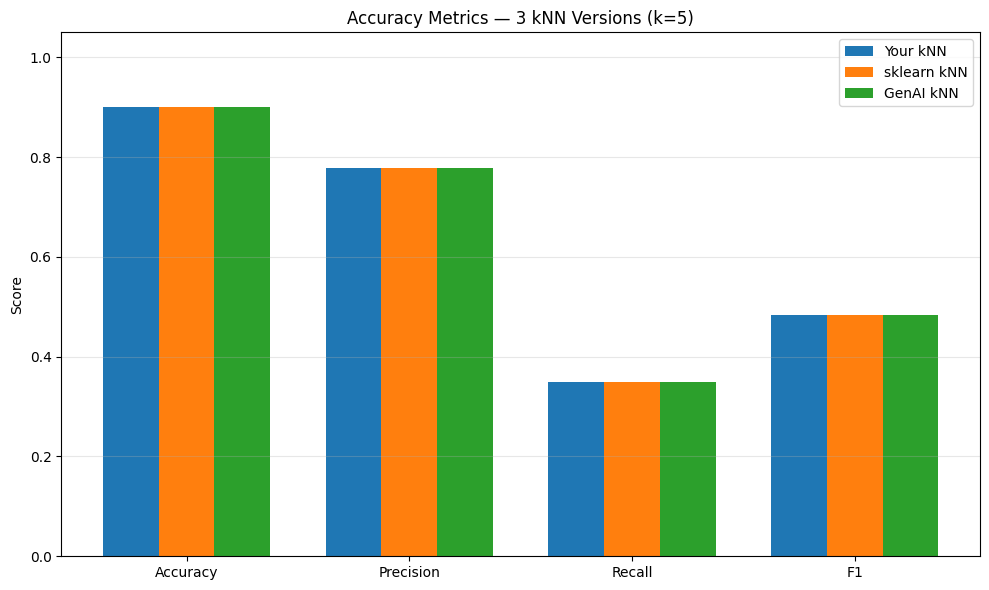

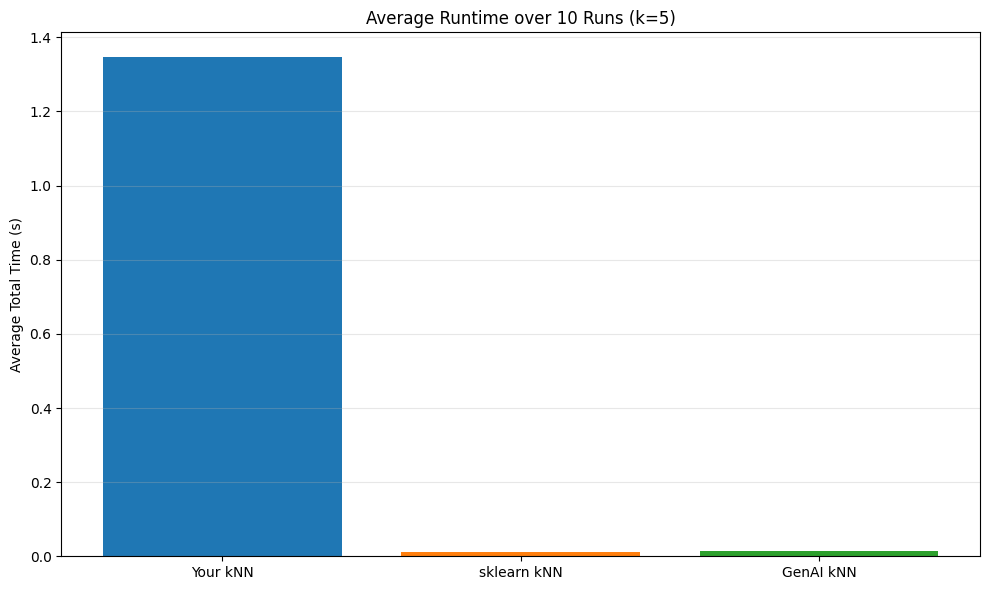

In [12]:
# ============================================================
# CELL 4: Plots for the report
# ============================================================
versions = ['Your kNN', 'sklearn kNN', 'GenAI kNN']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
results = [r1, r2, r3]

# --- Metric comparison bar chart ---
x = np.arange(len(metrics))
width = 0.25
plt.figure(figsize=(10, 6))
for i, (name, r) in enumerate(zip(versions, results)):
    vals = [r[m] for m in metrics]
    plt.bar(x + i * width, vals, width, label=name)
plt.xticks(x + width, metrics)
plt.ylabel("Score")
plt.title(f"Accuracy Metrics — 3 kNN Versions (k={k})")
plt.ylim(0, 1.05)
plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("lab06_metric_comparison.png", dpi=100)
plt.show()

# --- Runtime comparison bar chart ---
plt.figure(figsize=(10, 6))
totals = [r['Total Time (s)'] for r in results]
plt.bar(versions, totals, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel("Average Total Time (s)")
plt.title(f"Average Runtime over 10 Runs (k={k})")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("lab06_time_comparison.png", dpi=100)
plt.show()

